# O nezbednej ale múdrej gume
Tento projekt pomocou Autoencoder a U-Net "dopĺňa" čiastočne pogumované číslice

# Inštalácia knižníc
Tieto knižnice sú oddelené pretože napríklad inštalácia PyTorch sa môźe líšiť podĺa toho či používate CPU verziu alebo CUDA/ROCm

In [1]:
%pip install matplotlib

In [ ]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu # optional

# Importovanie knižníc
Používame tieto knižnice:
- PyTorch na trénovanie modelov a celkovo machine learning operácie
- NumPy na pokročilejšie a rýchlešie robenie s číselnými dátami
- Matplotlib na zobrazovanie ukážok
- Shutil na kopírovanie

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.nn.functional as F
import shutil

Potrebné len vtedy keď to beží na Google Colab a loadujete a ukladáte z Google Drive. Preto je to oddelené aby sa dalo spustiť aj lokálne

In [57]:
from google.colab import drive

# Importovanie a transformovanie datasetov
Aby sme mali dáta na trénovanie modelu tak sme potrebovali páry celých čísiel a tých pogumovaných, preto sme stiahli MNIST dataset ktorý obsahuje 70 tisíc kreslených čísiel. Zároveň ich transformujeme z fromátu PIL na PyTorch tensory

In [ ]:
# Definujeme transformáciu obrázkov
transform = transforms.Compose([transforms.ToTensor()])
# Tu sťahujeme datasety a delíme je na trénovacie a testovacie
mnist_train_raw = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test_raw = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 508kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.99MB/s]


# Funkcie na simulovanie gumy
Potrebovali sme niakym spôsobom nasimulovať gumu aby sa to model naučil dopĺňať. Tu používame Bézierovu krivku ktorá generuje hladké krivky. Vybrali sme ju, pretože bola najpodobnejšia tomu gumovaciemu efektu čo je v zadaní. Túto funkciu potom používame v samotnej gumovacej funkcii kde vygenerujeme štyri náhodne body v obrázku čísla, vytvoríme krivku a nakreslíme ju s definovanou hrúbkou čiernou farbou kedže obrázky z číslami su čiernobiele. Potom nakoniec konvertujeme numpy obrázok ako tensor.

In [4]:
def bezier_curve(p0, p1, p2, p3, n_points=100):
    t = np.linspace(0, 1, n_points)
    curve = (1-t)**3 * p0[:, None] + \
            3 * (1-t)**2 * t * p1[:, None] + \
            3 * (1-t) * t**2 * p2[:, None] + \
            t**3 * p3[:, None]
    return curve.T

In [ ]:
def erase_with_bezier(img_tensor, thickness=3):
    img = img_tensor.clone().squeeze().numpy()
    h, w = img.shape
    
    # Náhodné body pre krivku
    p0 = np.array([np.random.randint(-5, w+5), np.random.randint(-5, h+5)]) # Začiatok
    p3 = np.array([np.random.randint(-5, w+5), np.random.randint(-5, h+5)]) # Koniec
    p1 = np.array([np.random.randint(-10, w+10), np.random.randint(-10, h+10)]) # Zakrivenie 1
    p2 = np.array([np.random.randint(-10, w+10), np.random.randint(-10, h+10)]) # Zakrivenie 2

    # Výpočet bodov krivky
    curve_points = bezier_curve(p0, p1, p2, p3, n_points=60)

    # Kreslenie čiernou
    for x, y in curve_points:
        x, y = int(x), int(y)
        r_min_y, r_max_y = max(0, y-thickness), min(h, y+thickness)
        r_min_x, r_max_x = max(0, x-thickness), min(w, x+thickness)
        img[r_min_y:r_max_y, r_min_x:r_max_x] = 0.0

    return torch.from_numpy(img).unsqueeze(0).float()

#  Vytvorenie a caching tréningového datasetu
Tu sme vytvorili triedu ktorá slúži na to aby sme vytvorili ten dataset s pármi celých čísiel a tých pogumovaných. Kvôli optimalizácie tieto páry predgenerujem aby sa zrýchlilo trénovanie a nemuselo sa počas neho plýtvať čas a výkon na pogumovanie. Toto je hlavne citelné keď to beží len na CPU.

In [ ]:
class ErasedMNIST(Dataset):
    def __init__(self, mnist_dataset):
        self.mnist_dataset = mnist_dataset
        self.data = []
        
        print(f"Recalculating {len(mnist_dataset)} picutres")
        
        for idx in range(len(mnist_dataset)):
            clean_img, _ = mnist_dataset[idx]
            # Vytvoríme pogumovaný obrázok
            erased_img = erase_with_bezier(clean_img)
            # Uložíme si pár do pamäte
            self.data.append((erased_img, clean_img))
            
            # Výpis progresu každých 5000 obrázkov aby sme videli progres
            if (idx + 1) % 5000 == 0:
                print(f"Finished {idx + 1} / {len(mnist_dataset)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Vracia dáta z RAM
        return self.data[idx]

In [ ]:
# Tu už priamo vytvárame objekt z ErasedMNIST classy a ukladáme do premenných 
train_dataset = ErasedMNIST(mnist_train_raw)
test_dataset = ErasedMNIST(mnist_test_raw)
# Tu prebieha už loadovanie dát v batchoch aby už rovno mohli byť použité pri tréningu
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)


Predpočítavam 60000 obrázkov... (chvíľu to potrvá)
Hotovo 5000 / 60000
Hotovo 10000 / 60000
Hotovo 15000 / 60000
Hotovo 20000 / 60000
Hotovo 25000 / 60000
Hotovo 30000 / 60000
Hotovo 35000 / 60000
Hotovo 40000 / 60000
Hotovo 45000 / 60000
Hotovo 50000 / 60000
Hotovo 55000 / 60000
Hotovo 60000 / 60000
Predpočítavam 10000 obrázkov... (chvíľu to potrvá)
Hotovo 5000 / 10000
Hotovo 10000 / 10000


# Nastavenie modelu
Tu vytvárame triedu Autoencoder ktorá je postavená na architektúre U-Net. Vybrali sme U-Net pretože zachováva detaily obrázkup pomocou Skip Connections ktoré su také skratky čo umožnujú preskočiť priamo z encoderu do decoderu. Ďalej je stavaná na to aby vstup bol obrázok a aj výstup bol obrázok. A hlavne je efektívna na malých dátach napríklad ako máme my. V tejto triede definujeme encoding ktorým zmenšujeme obrázok až do velikosti 7 krát 7 pixelov a hlavne zvyšuje počet kanálov. Potom ide Bottleneck kde sa ešte zvýši počet kanálov, tu vidí ten model abstraktný obraz. A decoder zase zobere pochpopenie z bottlenecku a upsamplinguje ho až do pôvodného rozlíšenia. A priebežne poćas toho hľadá Skip connections.

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        
        # Spracuje vrstvu LeakyReLU
        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.LeakyReLU(0.2, inplace=True)
            )

        # Tu vytvárame encoder a tým pádom aj nové kanály
        self.enc1 = conv_block(1, 32)
        self.pool = nn.MaxPool2d(2, 2)
        
        self.enc2 = conv_block(32, 64)
        
        # Tu vytvárame Bottleneck a zvyšujeme opäť kanály
        self.center = conv_block(64, 128)
        # Vytvárame decoder s Skip Connections, tu sa upsamplinguje
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = conv_block(128, 64) 
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = conv_block(64, 32) 
        
        # Výsledný layer
        self.final = nn.Conv2d(32, 1, kernel_size=1)
    
    def forward(self, x):
        # Encoder, znižujeme rozlíšenie až na 7x7
        x1 = self.enc1(x)      # 28x28
        p1 = self.pool(x1)     # 14x14
        
        x2 = self.enc2(p1)     # 14x14
        p2 = self.pool(x2)     # 7x7
        
        # Bottleneck, najhlbšia analýza
        c = self.center(p2)    # 7x7
        
        # Decoder, tu opäť zase upsamplingujeme a skipujem connections
        d2 = self.up2(c)       # -> 14x14
        d2 = torch.cat([d2, x2], dim=1) # Skip connection
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)      # -> 28x28
        d1 = torch.cat([d1, x1], dim=1) # Skip connection
        d1 = self.dec1(d1)
        # Vráti finálny obrázok
        return torch.sigmoid(self.final(d1))

# Zistenie hardwaru a inicializácia modelu
Zistujeme či môžeme používať grafickú kartu alebo procesor. Zároveň inicializujeme inštanciu modelu

In [ ]:
# Tu nastavujeme že keď je dostupná Cuda tak používame ju
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Incializujeme model
model = Autoencoder().to(device)
# Zobrazí aké CPU/GPU používame
print(f"Running on: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Bežím na zariadení: cuda
Názov GPU: Tesla T4


# Trénovanie modelu
V tejto časti trénujeme samotný model. Prechádzame cez celý dataset toľko krát, koľko máme nastavený počet epochov, potom podľa chybovosti upravujeme weights a pokračujeme. Nakoniec model uložíme do súboru

In [ ]:
# Nastavujeme akým spôsobom počítame chybovosť, v tomto prípade používame L1Loss
criterion = nn.L1Loss()
# Konfigurujeme aký algortimus použijeme na upravovanie weights podla chybovosti
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Toto číslo nastavuje počet epochov(jeden cyklus cez trénovací dataset) pozor tu keď dáte moc vysoké čislo tak môźe nastať Overfitting
num_epochs = 16  
print("Training starts...")

for epoch in range(num_epochs):
    train_loss = 0.0
    # Tu prechádzame cez batche kedže celý dataset je nepraktické napchať do pamäte a jeden sample je neefektívny
    for inputs, targets in train_loader:
        # Presun na device 
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Vynulujeme gradienty z predchádzajúceho kroku
        optimizer.zero_grad()
        
        # Predikcia
        outputs = model(inputs)
        
        # Výpočítame chybovosť s porovnaním s originálnym obrázkom
        loss = criterion(outputs, targets)
        
        # Tu vypočítame gradienty a upravíme váhy
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)

    # Výpisujeme priemer chýb po každej epoche
    epoch_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

print("Training ended")

# 3. Uloženíme model (podľa zadania do súboru repairer.pth)
torch.save(model.state_dict(), 'repairer.pth')
print("Model saved to 'repairer.pth'")

Začína trénovanie...
Epoch [1/16], Loss: 0.0220
Epoch [2/16], Loss: 0.0214
Epoch [3/16], Loss: 0.0210
Epoch [4/16], Loss: 0.0207
Epoch [5/16], Loss: 0.0204
Epoch [6/16], Loss: 0.0202
Epoch [7/16], Loss: 0.0200
Epoch [8/16], Loss: 0.0197
Epoch [9/16], Loss: 0.0195
Epoch [10/16], Loss: 0.0192
Epoch [11/16], Loss: 0.0191
Epoch [12/16], Loss: 0.0189
Epoch [13/16], Loss: 0.0187
Epoch [14/16], Loss: 0.0185
Epoch [15/16], Loss: 0.0184
Epoch [16/16], Loss: 0.0182
Trénovanie ukončené!
Model uložený do 'repairer.pth'


# Vizualizácia porovnania testovacej sady
V tejto funkcii zobrazujeme porovnanie vstupu výstupu a originálu pomocou matplotlib.

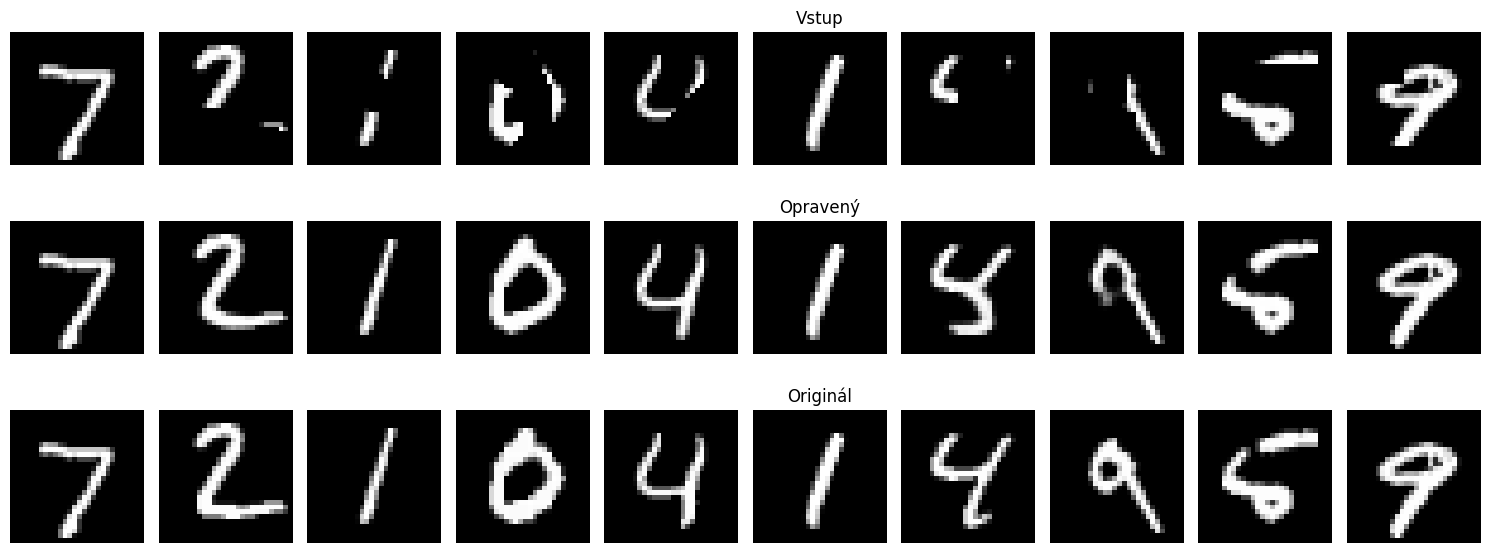

In [ ]:
# Funkcia na vizualizáciu porovnania poškedených zo testovacej sady a opravy
def visualize_results(model, loader):
    model.eval() # Prepneme sa do evaluačného módu
    images, clean_images = next(iter(loader))
    images, clean_images = images.to(device), clean_images.to(device)
    
    with torch.no_grad():
        outputs = model(images)
    
    # Presun spuť na CPU pre vykreslenie
    images = images.cpu().numpy()
    outputs = outputs.cpu().numpy()
    clean_images = clean_images.cpu().numpy()

    plt.figure(figsize=(15, 6))
    for i in range(10): # Zobrazíme 10 príkladov
        # Vstup (Poškodený)
        plt.subplot(3, 10, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        if i == 5: plt.title("Input")
        plt.axis('off')
        
        # Výstup (Opravený)
        plt.subplot(3, 10, i + 11)
        plt.imshow(outputs[i].squeeze(), cmap='gray')
        if i == 5: plt.title("Output")
        plt.axis('off')

        # Originál (Cieľ)
        plt.subplot(3, 10, i + 21)
        plt.imshow(clean_images[i].squeeze(), cmap='gray')
        if i == 5: plt.title("Original")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Zavoláme funkciu na testovacej sade
visualize_results(model, test_loader)

# Nastavenie ciest súborov
Nastavíme tu kde sa nachádza dataset čo chceme opraviť, kde má byť output a kde sa nachádza model

In [ ]:
input_path = '/content/drive/MyDrive/content/2000_rubbered_digits.pt'
output_path = '/content/drive/MyDrive/content/2000_fixed_digits.pt'
model_path = '/content/drive/MyDrive/content/repairer.pth'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/content/repairer.pth'

# OPTIONAL: Mountnutie Google Drivu
Toto sme použili kedže na vývoj sme používali Google Colab pripojený cez VS Code kedže procesor bol moc pomalý a ROCm zhadzovalo celý systém, tak sme museli nahodiť a stiahnuť tie súbory cez Google Drive

In [ ]:
drive.mount('/content/drive')
shutil.copy('repairer.pth', model_path)

# Opravenie pogumovaného datasetu
Naloadujeme zničený dataset, potom po batchoch ho celí opravíme a uložíme do jedného .pt súboru.

In [59]:
# Načítame vstupné dáta
rubbered_data = torch.load(input_path)
print(f"Loaded data for fixing: {rubbered_data.shape}")

# Inicializujeme model
model = Autoencoder().to(device)
model.load_state_dict(torch.load('repairer.pth', map_location=device))
model.eval()

# Vytvoríme DataLoader pre efektívnejšie loadovanie s batching
inference_dataset = torch.utils.data.TensorDataset(rubbered_data)

inference_loader = DataLoader(inference_dataset, batch_size=64, shuffle=False)

fixed_list = []
print("Fixing images...")

with torch.no_grad():
    for batch in inference_loader:
        imgs = batch[0].to(device)
        
        # Aplikujeme model
        outputs = model(imgs)
        
        # Presunieme výsledky na CPU a pridáme do zoznamu
        fixed_list.append(outputs.cpu())

# Spojíme všetky batch-e do jedného veľkého tenzora
fixed_digits = torch.cat(fixed_list, dim=0)

# Uložíme do súboru
torch.save(fixed_digits, output_path)
print(f"Finished! Fixed data saved to '{output_path}' (Shape: {fixed_digits.shape})")



Loaded data for fixing: torch.Size([2000, 1, 28, 28])
Fixing images...
Finished! Fixed data saved to '/content/drive/MyDrive/content/2000_fixed_digits.pt' (Shape: torch.Size([2000, 1, 28, 28]))


# Vizualizácia porovnania zadania s predikciami
Porovnávame cez matplotlib pogumované číslice zo zadania a ako ich model opravil.

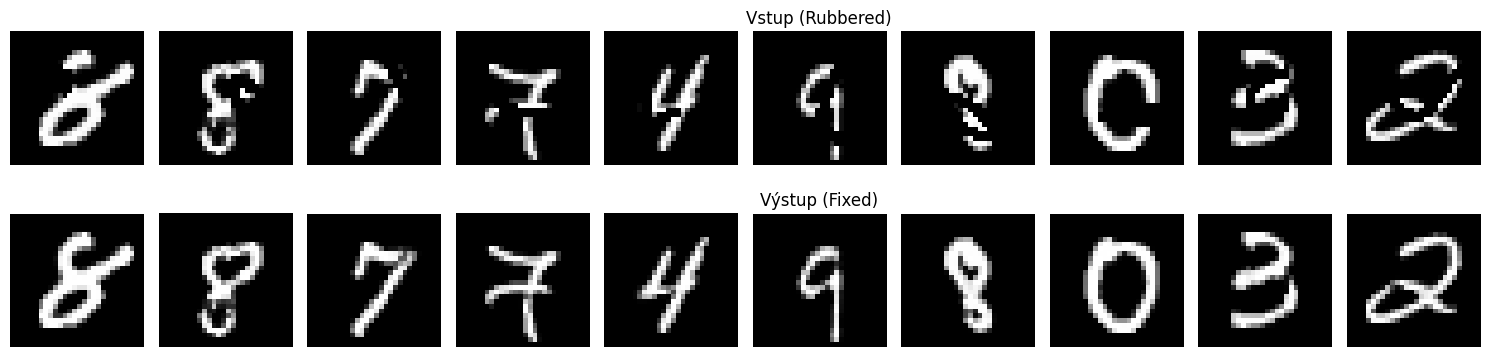

In [58]:
#  Vizualizácia porovnania poškedených zo zadania a opravy
plt.figure(figsize=(15, 4))
for i in range(10):
    # Pôvodný poškodený
    plt.subplot(2, 10, i + 1)
    plt.imshow(rubbered_data[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 5: plt.title("Vstup (Rubbered)")

    # Opravený modelom
    plt.subplot(2, 10, i + 11)
    plt.imshow(fixed_digits[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 5: plt.title("Výstup (Fixed)")

plt.tight_layout()
plt.show()